# SNAP Payment Error - Data Exploration

Notes:
- one row = one household/case
- `error_target` = 1 if Error > 0 (but that's NOT the FNS $ threshold, those are FY specific: 2025=$57, 2024=$56, 2023=$54, 2022=$48)
- data dictionary = the *updated* xlsx (Jun 2 one), the other one was the draft
- supposedly 3659 rows x 57 cols per the briefing report... let's see if that's right

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
sns.set_theme(style="whitegrid")

df = pd.read_csv("Data_UVA_SNAProject.csv")
df.shape

(3658, 57)

In [2]:
df.head()

,case_ern_incm_amt,case_uern_incm_amt,case_slf_ern_incm_amt,tot_shl_cost_amt,mdate,av_age,med_age,flag_monoeth,flag_monolang,case_english,case_nonenglish,family_size,max_educ,tt_income,self_empl,is_children,unit_children,is_disable,unit_disable,is_old,is_married,is_separated,move_flag,Error,error_target,new_err,grouprace,homeless_allow_amt,bas_utl_allow_amt,med_exp_amt,chld_sup_exp_amt,pctchg_unearned_inc,pctchg_earned_inc,pctchg_shelter_cost,aboveavg_uern_fips,aboveavg_ern_fips,aboveavg_shl_fips,caseload,job_tenure,dss_tenure,va_region,job_category,group_region,Type,Classification,Issuance,main_error_type,total_income,round_income,round_income_un,share_rent,flag_inchh,inc_cap,max_snap,share_issuance,new_case_num,new_emp_num
0,3464.74,0.0,0.0,501.00000,2022m8,10.833333,8.5,1,1,1,0,6,99,3464.74,0,1,5,0.0,0,0,1,0,0.0,41,1,41,1,0.0,201.00000,0.0,0.0,NaN,5.00612,NaN,0.0,1.0,0.0,773.0,0.0,69.0,Central,Benefit Programs,1,1. Complete,2. Overissuance,432,311. Wages and salaries,3464.74,0.0,0.0,0.144558,1.0,577.456667,1421.0,0.304011,2463,336
1,1545.74,0.0,0.0,1487.96000,2023m11,20.333334,15.0,0,1,1,0,3,99,1545.74,0,1,2,0.0,0,0,0,0,0.0,0,0,0,2,0.0,287.95999,0.0,0.0,NaN,NaN,NaN,0.0,1.0,1.0,4113.0,0.0,55.0,Northern,Benefit Programs,3,3. Incomplete,NaN,655,NaN,1545.74,0.0,0.0,0.961997,1.0,515.246667,785.0,0.834395,2511,1506
2,0.00,1040.0,0.0,715.78003,2025m3,67.000000,67.0,1,1,1,0,1,99,1040.00,0,0,0,1.0,1,1,0,1,0.0,97,1,97,1,0.0,369.00000,0.0,0.0,4.522613,NaN,NaN,1.0,0.0,1.0,1600.0,0.0,54.0,Piedmont,Benefit Programs,4,1. Complete,2. Overissuance,130,"331. Retirement, Survivors, and Disability Ins...",1040.00,0.0,1.0,0.687589,0.0,1040.000000,298.0,0.436242,2227,338
3,NaN,NaN,NaN,0.00000,2021m12,29.500000,29.5,1,1,1,0,2,1,NaN,1,1,1,0.0,0,0,0,1,NaN,1,1,1,4,0.0,0.00000,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,1376.0,84.0,119.0,Western,Benefit Programs,5,1. Complete,2. Overissuance,337,520. Arithmetic computation,NaN,NaN,NaN,NaN,0.0,NaN,546.0,0.617216,526,1780
4,0.00,861.0,0.0,967.00000,2022m9,65.000000,65.0,1,1,1,0,1,2,861.00,0,0,0,1.0,1,1,0,0,0.0,34,1,-34,1,0.0,374.00000,0.0,0.0,5.773956,NaN,NaN,1.0,0.0,1.0,1590.0,66.0,66.0,Piedmont,Miscellaneous / Other,4,1. Complete,3. Underissuance,216,363. Shelter deduction,861.00,0.0,1.0,1.121810,0.0,861.000000,298.0,0.724832,195,523


In [ ]:
df.dtypes.value_counts()

float64    30
int64      21
object      6
Name: count, dtype: int64

In [ ]:
df.dtypes

case_ern_incm_amt        float64
case_uern_incm_amt       float64
case_slf_ern_incm_amt    float64
tot_shl_cost_amt         float64
mdate                     object
av_age                   float64
med_age                  float64
flag_monoeth               int64
flag_monolang              int64
case_english               int64
case_nonenglish            int64
family_size                int64
max_educ                   int64
tt_income                float64
self_empl                  int64
is_children                int64
unit_children              int64
is_disable               float64
unit_disable               int64
is_old                     int64
is_married                 int64
is_separated               int64
move_flag                float64
Error                      int64
error_target               int64
new_err                    int64
grouprace                  int64
homeless_allow_amt       float64
bas_utl_allow_amt        float64
med_exp_amt              float64
chld_sup_e

### cross-checking columns against the data dictionary

The dictionary lists the 4 supplementary vars as `Flag_inchh`, `Max_snap`, `Inc_cap`,
`Share_issuance` (capitalized) but in the actual csv they're lowercase. small thing but
will matter when i merge/reference the dictionary later.

In [5]:
dict_names = ['new_case_num','Error','error_target','new_err','va_region','group_region',
 'case_ern_incm_amt','case_uern_incm_amt','tot_shl_cost_amt','mdate','av_age','med_age',
 'grouprace','flag_monolang','case_english','family_size','max_educ','self_empl',
 'unit_children','unit_disable','is_old','is_separated','move_flag','homeless_allow_amt',
 'bas_utl_allow_amt','med_exp_amt','chld_sup_exp_amt','pctchg_unearned_inc','pctchg_earned_inc',
 'pctchg_shelter_cost','aboveavg_uern_fips','aboveavg_ern_fips','aboveavg_shl_fips','new_emp_num',
 'dss_tenure','caseload','job_category','round_income','round_income_un','share_rent',
 'Flag_inchh','Max_snap','Inc_cap','Share_issuance','case_slf_ern_incm_amt','flag_monoeth',
 'case_nonenglish','tt_income','is_children','is_disable','is_married','Type','Classification',
 'Issuance','main_error_type','total_income','job_tenure']

csv_cols = set(df.columns)
# case-insensitive match
csv_lower = {c.lower() for c in df.columns}
missing_from_csv = [c for c in dict_names if c.lower() not in csv_lower]
extra_in_csv = [c for c in df.columns if c.lower() not in {d.lower() for d in dict_names}]
print("in dictionary but not in csv:", missing_from_csv)
print("in csv but not in dictionary:", extra_in_csv)

in dictionary but not in csv: []
in csv but not in dictionary: []


everything lines up (case-insensitively). good, 57 = 57.

## missing values

this is the thing i actually care about most right now.

In [6]:
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(1)
pd.DataFrame({'n_missing': miss, 'pct': miss_pct})

,n_missing,pct
pctchg_shelter_cost,3581,97.9
pctchg_earned_inc,3092,84.5
main_error_type,2303,63.0
pctchg_unearned_inc,2132,58.3
Classification,939,25.7
share_rent,428,11.7
bas_utl_allow_amt,390,10.7
chld_sup_exp_amt,390,10.7
med_exp_amt,390,10.7
homeless_allow_amt,390,10.7


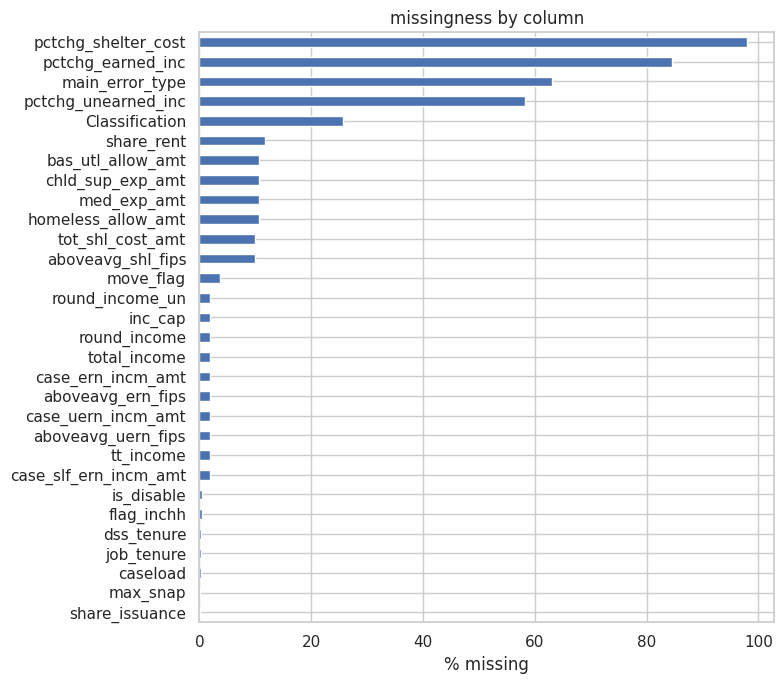

In [7]:
fig, ax = plt.subplots(figsize=(8,7))
miss_pct.sort_values().plot.barh(ax=ax)
ax.set_xlabel("% missing")
ax.set_title("missingness by column")
plt.tight_layout()
plt.show()

things that jump out:
- `pctchg_shelter_cost` is missing 97% of the time, `pctchg_earned_inc` 85%. these YoY change
  vars are basically empty. probably only computed when there's a prior year to compare? might
  not be usable as features.
- `main_error_type` missing 2303 times ~ which is almost exactly the number of non-error cases
  (2301). makes sense -> no error = no error type. so this is only defined for error cases.
- `Classification` missing 939. need to check if those are the "Incomplete" review types.
- a chunk of income/shelter vars all missing the same 70 / 362 / 390 rows -> looks like
  whole-row groups are missing. **TODO: check if these are the same rows.**

In [8]:
# are the 70-missing income cols all the SAME rows?
inc_cols = ['case_ern_incm_amt','case_uern_incm_amt','case_slf_ern_incm_amt','tt_income','total_income','inc_cap']
print("rows missing each:", {c: int(df[c].isna().sum()) for c in inc_cols})
print("rows missing ALL of them:", int(df[inc_cols].isna().all(axis=1).sum()))

rows missing each: {'case_ern_incm_amt': 70, 'case_uern_incm_amt': 70, 'case_slf_ern_incm_amt': 70, 'tt_income': 70, 'total_income': 70, 'inc_cap': 70}
rows missing ALL of them: 70


yep, same 70 rows missing across all the income columns. so it's a group of cases with no income data at all, not random.

## the target(s)

There are basically 3 error-related columns: `Error` (abs $), `error_target` (0/1), and
`new_err` (signed: + over / - under). Let me make sure i understand how they relate.

In [9]:
print(df['error_target'].value_counts())
print()
print("error rate:", round(df['error_target'].mean(), 3))

error_target
0    2301
1    1357
Name: count, dtype: int64

error rate: 0.371


so about **37%** of cases have some error (>$0). that's the naive target. fairly balanced actually, nice.

In [10]:
# sanity check: error_target should be 1 exactly when Error > 0
check = ((df['Error'] > 0).astype(int) == df['error_target']).all()
print("error_target == (Error>0) for every row?", check)

# and |new_err| should equal Error
print("abs(new_err) == Error for every row?", (df['new_err'].abs() == df['Error']).all())

error_target == (Error>0) for every row? True
abs(new_err) == Error for every row? True


In [11]:
# over vs under vs correct, using new_err sign
print("underissuance (new_err<0):", (df['new_err'] < 0).sum())
print("correct (==0):           ", (df['new_err'] == 0).sum())
print("overissuance (new_err>0):", (df['new_err'] > 0).sum())

underissuance (new_err<0): 461
correct (==0):            2301
overissuance (new_err>0): 896


so of the 1357 error cases, ~896 are overissuance (we gave too much) and ~461 underissuance.
overissuance is the bigger chunk, which tracks with why VDSS cares (overpayments = $ lost).

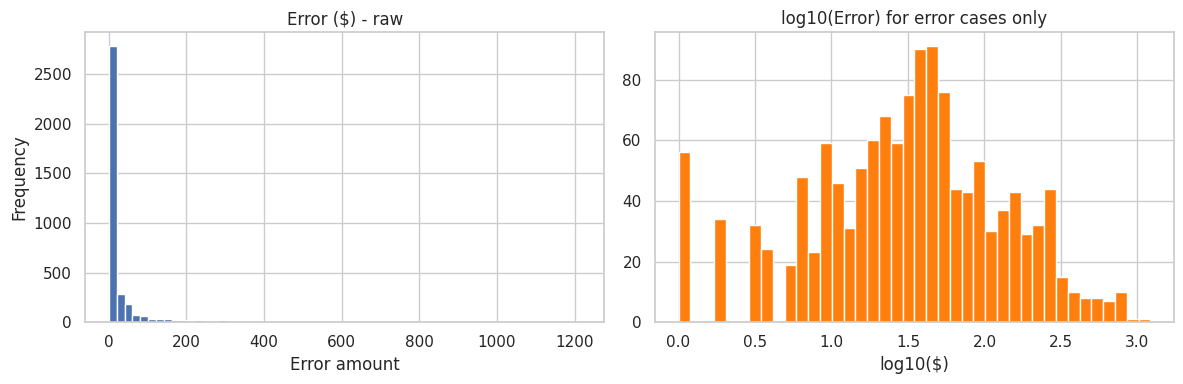

count    3658.000000
mean       28.224986
std        82.432432
min         0.000000
25%         0.000000
50%         0.000000
75%        18.000000
max      1216.000000
Name: Error, dtype: float64

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
df['Error'].plot.hist(bins=60, ax=axes[0])
axes[0].set_title("Error ($) - raw")
axes[0].set_xlabel("Error amount")

# log scale on the nonzero ones bc it's super skewed
nz = df.loc[df['Error'] > 0, 'Error']
axes[1].hist(np.log10(nz), bins=40, color='tab:orange')
axes[1].set_title("log10(Error) for error cases only")
axes[1].set_xlabel("log10($)")
plt.tight_layout()
plt.show()

df['Error'].describe()

extremely right-skewed (median is literally 0 bc most cases have no error). among actual
errors the distribution is wide, max is \$1216. if we ever model the dollar amount we'll
probably need a log transform.

note: the FNS thresholds (~\$48-57) matter here. a lot of these small errors are below the
threshold so they might not "count" as official errors. **question for Arthur: do we filter
those out?**

In [13]:
# how many error cases fall UNDER the rough FNS threshold? (using ~$57 as a quick proxy)
err_cases = df[df['Error'] > 0]
under_thresh = (err_cases['Error'] <= 57).mean()
print(f"share of error cases at/under ~$57: {under_thresh:.1%}")
print("so a real chunk of 'errors' are tiny. matters for how we define the target.")

share of error cases at/under ~$57: 69.0%
so a real chunk of 'errors' are tiny. matters for how we define the target.


## numeric features

big describe table, then i'll histogram the ones that look interesting.

In [14]:
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols].describe().T[['count','mean','std','min','50%','max']].round(1)

,count,mean,std,min,50%,max
case_ern_incm_amt,3588.0,468.5,929.2,0.0,0.0,5751.6
case_uern_incm_amt,3588.0,579.9,647.9,0.0,414.5,3538.0
case_slf_ern_incm_amt,3588.0,28.3,199.0,0.0,0.0,3861.6
tot_shl_cost_amt,3296.0,644.9,569.9,0.0,552.0,4210.0
av_age,3658.0,40.8,22.0,0.0,37.0,97.0
med_age,3658.0,39.7,23.5,0.0,37.0,97.0
flag_monoeth,3658.0,0.9,0.2,0.0,1.0,1.0
flag_monolang,3658.0,1.0,0.2,0.0,1.0,1.0
case_english,3658.0,1.0,0.2,0.0,1.0,1.0
case_nonenglish,3658.0,0.1,0.2,0.0,0.0,1.0


few weird things i want to look closer at:
- `share_issuance` max is **1.20** -- the dictionary says it should be between 0 and 1
  (Issuance / Max_snap). so some households got *more* than the theoretical max? maybe disability
  cases (Max_snap ignores disability per Arthur's email). worth a note.
- `caseload` goes up to ~25,900 which seems really high for "avg cases handled"... units?
- `max_educ` uses 99 for unknown and that's ~35% of rows, that's a lot of unknowns.

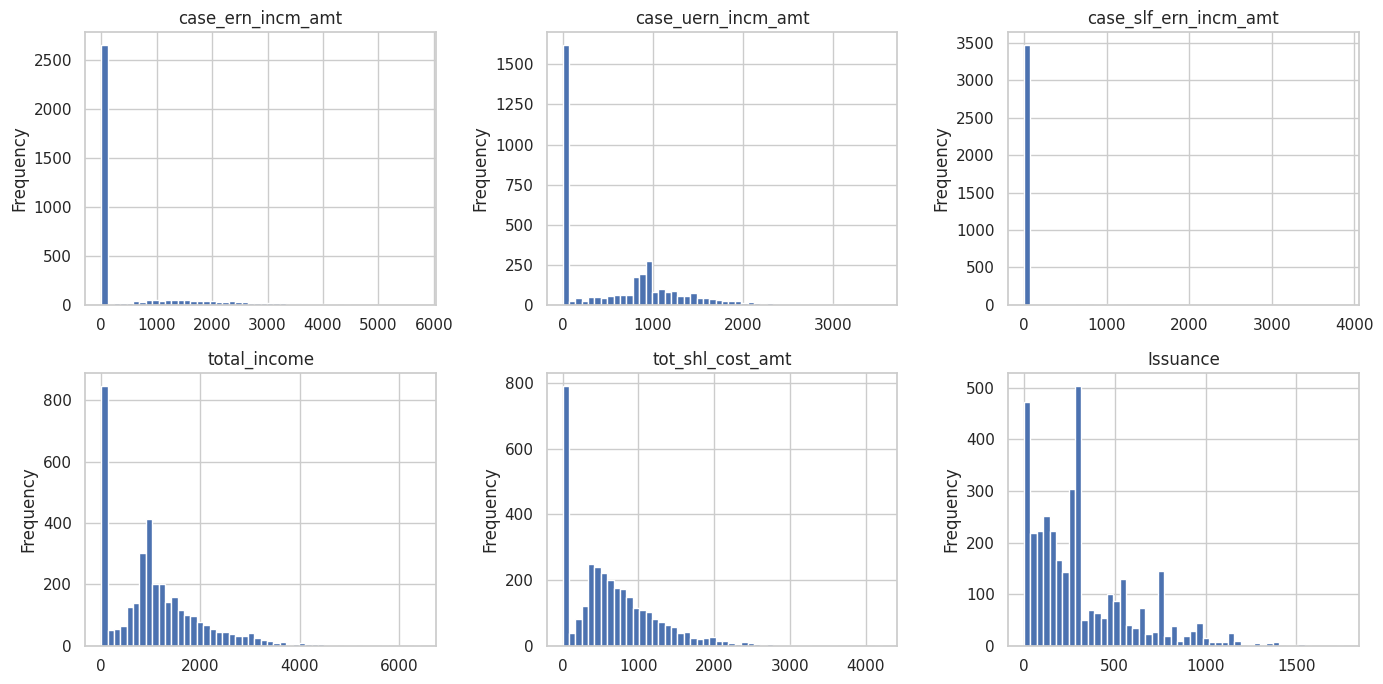

In [15]:
# income distributions
fig, axes = plt.subplots(2, 3, figsize=(14,7))
for ax, c in zip(axes.ravel(),
                 ['case_ern_incm_amt','case_uern_incm_amt','case_slf_ern_incm_amt',
                  'total_income','tot_shl_cost_amt','Issuance']):
    df[c].plot.hist(bins=50, ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

earned income has a huge spike at 0 -> lots of households with no earned income (makes sense,
SNAP). unearned income is more spread out (benefits etc). self-employment is almost all 0.

In [16]:
# the share_issuance > 1 cases - who are they?
weird = df[df['share_issuance'] > 1]
print("rows with share_issuance > 1:", len(weird))
print("are they disabled?  is_disable mean:", round(weird['is_disable'].mean(), 2),
      "(overall:", round(df['is_disable'].mean(), 2), ")")
weird[['Issuance','max_snap','share_issuance','is_disable','family_size']].head()

rows with share_issuance > 1: 2
are they disabled?  is_disable mean: 0.0 (overall: 0.34 )


,Issuance,max_snap,share_issuance,is_disable,family_size
695,658,546.0,1.205128,0.0,2
1007,786,785.0,1.001274,0.0,3


hmm only a handful, and they do skew disabled. so my disability theory is plausible. flagging for Arthur anyway.

## categorical / coded variables

In [17]:
for c in ['va_region','group_region','job_category','Type','grouprace','max_educ']:
    print("====", c, "====")
    print(df[c].value_counts(dropna=False))
    print()

==== va_region ====
va_region
Eastern     1007
Northern     789
Central      735
Piedmont     730
Western      397
Name: count, dtype: int64

==== group_region ====
group_region
2    1007
3     789
1     735
4     730
5     397
Name: count, dtype: int64

==== job_category ====
job_category
Benefit Programs         2504
Human/Social Services     792
Eligibility               281
Miscellaneous / Other      81
Name: count, dtype: int64

==== Type ====
Type
1. Complete                 2708
3. Incomplete                802
2. Not subject to review     148
Name: count, dtype: int64

==== grouprace ====
grouprace
4    1737
1    1535
2     223
3     163
Name: count, dtype: int64

==== max_educ ====
max_educ
2     1762
99    1269
4      469
1      158
Name: count, dtype: int64



notes:
- `va_region` (5 labels) and `group_region` (1-5) are the same thing, just label vs code.
  Eastern=2, Northern=3, Central=1, Piedmont=4, Western=5 based on the counts lining up.
- `Type` has these "1. Complete / 2. Not subject to review / 3. Incomplete" string prefixes,
  kind of annoying to work with, will want to clean those.
- `grouprace` is 1/2/3/4, no label key in the dictionary -> **need the mapping from Arthur.**

In [18]:
# Classification is messy - looks like there are near-duplicate FNS labels
df['Classification'].value_counts(dropna=False)

Classification
1. Amount correct                                                                              1361
NaN                                                                                             939
2. Overissuance                                                                                 842
3. Underissuance                                                                                461
4. Ineligible for not meeting conditions of eligibility                                          27
4. Ineligible                                                                                    21
5. Ineligible for non-compliance with a required process for issuing or continuing benefits       7
Name: count, dtype: int64

yeah this is messy. there are basically duplicate categories:
- "4. Ineligible" vs "4. Ineligible for not meeting conditions of eligibility"
- the "5. Ineligible for non-compliance..." one

these are probably coming from the 4 different yearly source files using slightly different
wording. **will need to standardize these before using Classification.** the NaNs (939) likely
= incomplete reviews, checking that next.

In [19]:
# is missing Classification == Incomplete review type?
pd.crosstab(df['Type'], df['Classification'].isna(), dropna=False)

Classification,False,True
Type,,
1. Complete,2708,0
2. Not subject to review,0,148
3. Incomplete,11,791


interesting - the 802 "Incomplete" cases are all missing Classification (good, expected),
but there's also ~137 "Not subject to review" missing. so missing Classification mostly = not
a completed review. so if we model on Classification we should probably restrict to Complete cases.

In [20]:
# main_error_type - also has near-dup labels (e.g. RSDI written 2 ways, SSI 3 ways)
df['main_error_type'].value_counts(dropna=False).head(20)

main_error_type
NaN                                                                                            2303
363. Shelter deduction                                                                          398
311. Wages and salaries                                                                         285
364. Standard utility allowance                                                                 130
331. Retirement, Survivors, and Disability Insurance (RSDI) benefits                             53
365. Medical expense deductions                                                                  52
312. Self-employment                                                                             45
520. Arithmetic computation                                                                      44
150. Unit composition                                                                            38
331. RSDI benefits                                                                  

same story - "331. RSDI benefits" and "331. Retirement, Survivors, and Disability Insurance
(RSDI) benefits" are the same code different text. could clean by just taking the leading number
code. there are ~40 distinct strings but probably way fewer actual codes.

In [21]:
# clean idea: take the numeric FNS code prefix
df['err_code'] = df['main_error_type'].str.extract(r'^(\d+)')
print("distinct raw strings:", df['main_error_type'].nunique())
print("distinct leading codes:", df['err_code'].nunique())
df['err_code'].value_counts().head(10)

distinct raw strings: 40
distinct leading codes: 31


err_code
363    398
311    285
364    130
331     87
333     68
365     52
350     51
312     45
520     44
150     38
Name: count, dtype: int64

yep! 40 strings collapse to way fewer codes. `363` (shelter deduction) and `311` (wages) are
the most common error sources. that's a useful finding on its own - shelter and wage errors
dominate.

## relationships with the target

does error rate vary by group? quick cuts.

               mean  count
va_region                 
Central    0.428571    735
Eastern    0.366435   1007
Western    0.357683    397
Northern   0.354880    789
Piedmont   0.343836    730


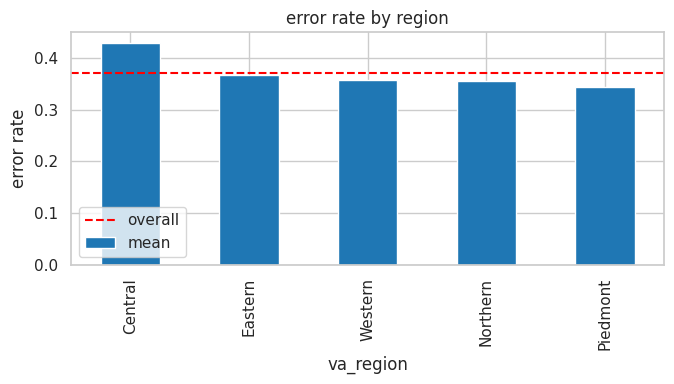

In [22]:
# error rate by region
reg = df.groupby('va_region')['error_target'].agg(['mean','count']).sort_values('mean', ascending=False)
print(reg)

fig, ax = plt.subplots(figsize=(7,4))
reg['mean'].plot.bar(ax=ax, color='tab:blue')
ax.set_ylabel("error rate")
ax.set_title("error rate by region")
ax.axhline(df['error_target'].mean(), color='red', ls='--', label='overall')
ax.legend()
plt.tight_layout()
plt.show()

Central is highest (~43%) vs the rest around 34-37%. not a giant difference but Central stands out a bit.

                 mean  count
family_size                 
1            0.336256   1939
2            0.384252    635
3            0.408421    475
4            0.474026    308
5            0.372340    188
6            0.428571     77
7            0.454545     22
8            0.545455     11
9            0.500000      2
11           1.000000      1


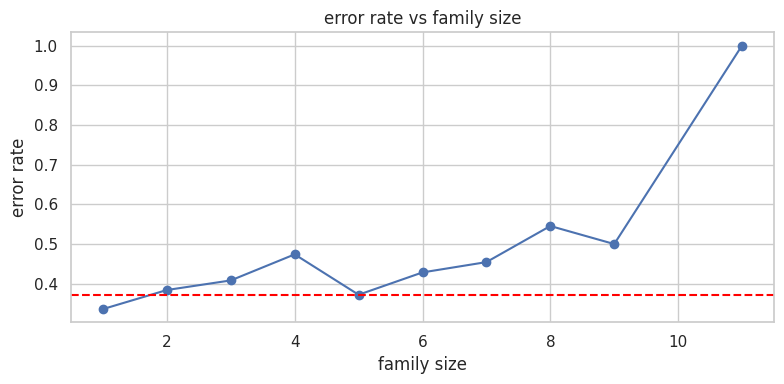

In [23]:
# error rate by family size
fs = df.groupby('family_size')['error_target'].agg(['mean','count'])
print(fs)
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(fs.index, fs['mean'], marker='o')
ax.axhline(df['error_target'].mean(), color='red', ls='--')
ax.set_xlabel("family size"); ax.set_ylabel("error rate")
ax.set_title("error rate vs family size")
plt.tight_layout(); plt.show()

generally trends up with family size (bigger households = more complex cases = more error?),
though the big sizes have tiny counts so i wouldn't read too much into 8+. family size 1 is the
huge group (1939 cases) and has the lowest rate.

In [24]:
# mean Error $ by error code (only error cases), top sources
g = df[df['Error']>0].groupby('err_code')['Error'].agg(['mean','count'])
g[g['count']>=20].sort_values('mean', ascending=False).head(10).round(1)

,mean,count
err_code,,
150,185.8,38
311,117.9,284
312,98.9,45
323,64.7,23
350,62.3,51
365,59.4,52
342,51.1,26
364,50.9,130
331,47.4,87


`150` (unit composition) errors are the biggest on average (~\$186) even though there aren't
many. wage errors (311) are both common AND big. so if VDSS wants high \$-per-case, unit
composition + wage errors look like the place to look.

## correlations between numeric vars

just to spot redundancy and anything correlated with Error.

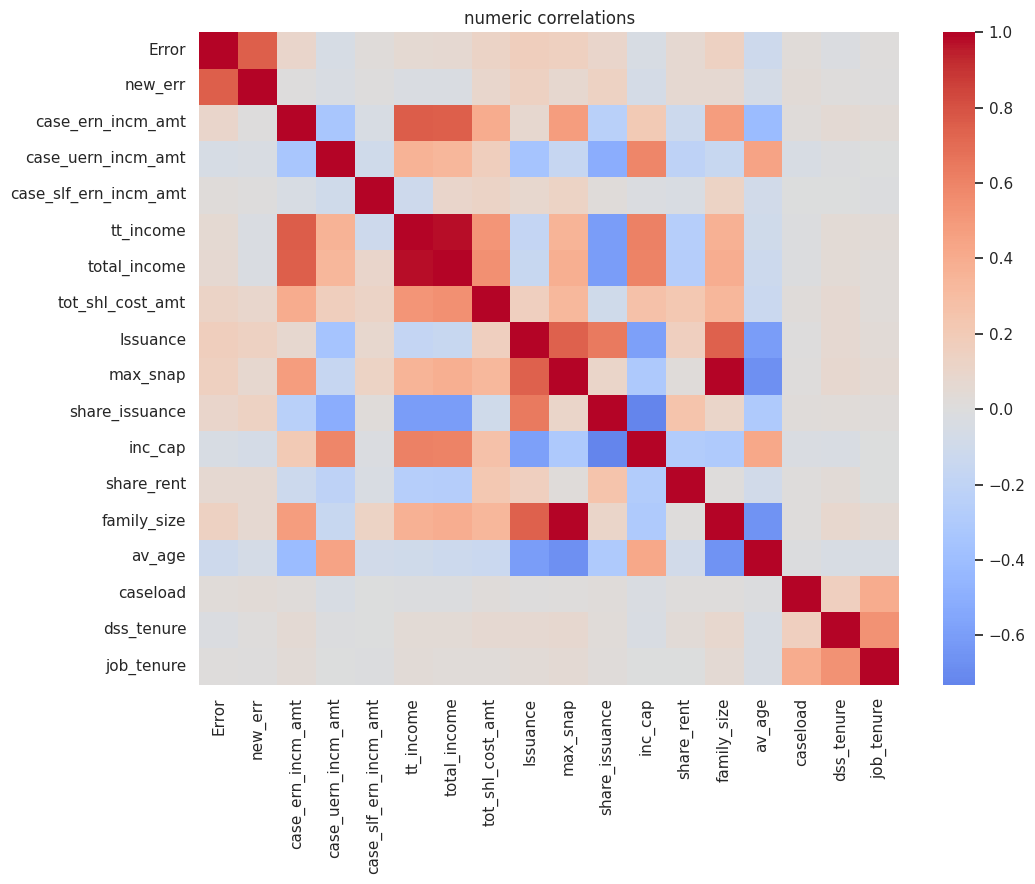

In [25]:
corr_cols = ['Error','new_err','case_ern_incm_amt','case_uern_incm_amt','case_slf_ern_incm_amt',
 'tt_income','total_income','tot_shl_cost_amt','Issuance','max_snap','share_issuance','inc_cap',
 'share_rent','family_size','av_age','caseload','dss_tenure','job_tenure']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11,9))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, ax=ax)
ax.set_title("numeric correlations")
plt.tight_layout(); plt.show()

In [26]:
# what correlates most with Error?
corr['Error'].drop('Error').sort_values(key=abs, ascending=False).head(10).round(3)

new_err              0.752
Issuance             0.164
max_snap             0.150
family_size          0.145
tot_shl_cost_amt     0.127
av_age              -0.115
share_issuance       0.100
case_ern_incm_amt    0.095
share_rent           0.065
total_income         0.064
Name: Error, dtype: float64

honestly nothing correlates strongly with the raw Error amount (top is ~0.1-ish). not
surprising given how zero-inflated and skewed it is. linear correlation probably isn't the right
lens; tree models or looking at error *occurrence* will likely do better. `tt_income` and
`total_income` are near-perfectly correlated (obviously, total just adds self-employment) so
i'd only keep one in a model.

## timing - mdate

format is like `2022m8`. let me parse it into year/month and map to fiscal year so i can line
it up with the FNS thresholds later.

In [27]:
mt = df['mdate'].str.extract(r'(?P<year>\d{4})m(?P<month>\d{1,2})').astype(int)
df['cal_year'] = mt['year']
df['cal_month'] = mt['month']
# federal fiscal year: Oct-Sep, FY labeled by the year it ENDS in
df['fy'] = np.where(df['cal_month'] >= 10, df['cal_year'] + 1, df['cal_year'])
df['fy'].value_counts().sort_index()

fy
2022    1051
2023     787
2024    1079
2025     741
Name: count, dtype: int64

so the data spans FY2022-FY2026ish. pretty even across years which is good (4 yearly files like Arthur said).

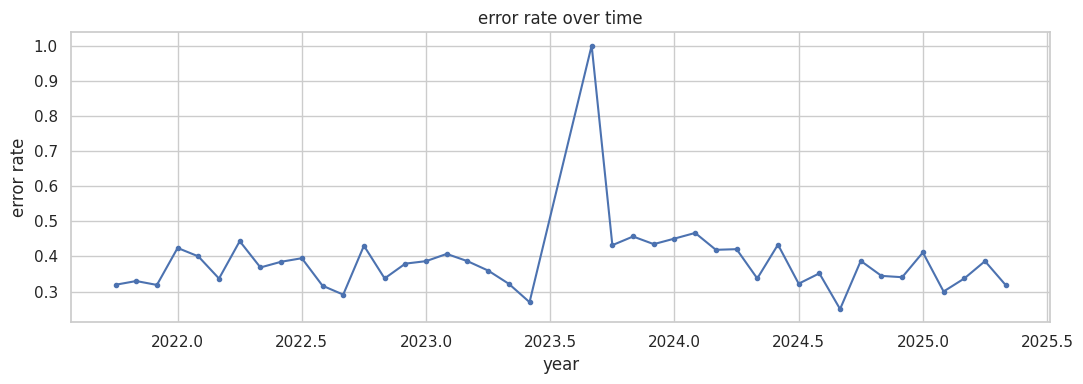

In [28]:
# error rate over time (by calendar year-month)
ts = (df.assign(ym=df['cal_year'] + (df['cal_month']-1)/12)
        .groupby('ym')['error_target'].mean())
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(ts.index, ts.values, marker='.')
ax.set_title("error rate over time")
ax.set_ylabel("error rate"); ax.set_xlabel("year")
plt.tight_layout(); plt.show()

pretty noisy month to month, no obvious trend jumping out. would need to smooth / aggregate to say anything real.

## summary + questions for Arthur

**what i learned:**
- 3658 rows (not 3659), 57 cols, one row per case. columns match the dictionary (case-insensitively).
- ~37% of cases have an error (`error_target`). of those, ~2/3 overissuance, ~1/3 underissuance.
- Error \$ is super skewed / zero-inflated, max \$1216. log transform needed if we model the amount.
- shelter deduction (363) and wages (311) are the most common error sources; unit composition (150)
  and wages have the highest average dollar errors.
- nothing correlates strongly with raw Error -> occurrence/category models or trees probably better than linear.

**data quality stuff to fix:**
- `Classification` and `main_error_type` have near-duplicate labels from the 4 source files -> standardize
  (extracting the numeric code works well).
- `pctchg_*` columns are 85-97% missing -> probably not usable.
- income/shelter vars missing in consistent row-groups (70 / 362 / 390), not random.
- `max_educ` = 99 (unknown) for ~35% of rows.
- `share_issuance` > 1 for a few cases (should be <=1) - seems disability-related.

**questions for Arthur:**
1. mapping for `grouprace` codes (1-4)? no label key given.
2. do we exclude sub-threshold errors (the ~\$48-57 FNS cutoffs) when defining the target?
3. are the YoY `pctchg_*` columns supposed to be that empty, or did something break?
4. is `caseload` really up to ~25k? want to confirm units.
5. for category modeling - use cleaned numeric error codes or the full FNS text?

next: bring the cleaning ideas to the team Sunday, then once we hear back, start on a first model.